In [1]:
!pip install requests beautifulsoup4 pandas lxml

In [ ]:
import requests
import pandas as pd
import time

# Step 1 — City & Area Data with Lat/Long


city_areas_latlong = {

    # Bangalore
    "bangalore": [
        ("indiranagar", 12.971891, 77.641151),
        ("whitefield", 12.967995, 77.749955),
        ("koramangala", 12.935223, 77.624954),
        ("btm", 12.916527, 77.610116),
        ("hsr", 12.911559, 77.647822),
        ("marathahalli", 12.959138, 77.697403),
        ("jayanagar", 12.935193, 77.624207),
        ("rajajinagar", 13.022501, 77.549100),
        ("hebbal", 13.040555, 77.603333),
        ("bellandur", 12.916483, 77.689823),
        ("electronic-city", 12.839444, 77.677222),
        ("yelahanka", 13.100000, 77.590000),
        ("banashankari", 12.914169, 77.571133),
        ("basavanagudi", 12.949374, 77.570167),
        ("kalyan-nagar", 13.021687, 77.644020),
        ("sarjapur-road", 12.914129, 77.701081),
        ("jp-nagar", 12.915175, 77.587197),
        ("cv-raman-nagar", 13.025597, 77.701080),
        ("malleshwaram", 13.009405, 77.569233),
        ("kr-puram", 13.024548, 77.709679)
    ],

    # Chennai
    "chennai": [
        ("t-nagar", 13.041667, 80.236389),
        ("anna-nagar-east", 13.060440, 80.212006),
        ("velachery", 12.978000, 80.226780),
        ("adyar", 12.988334, 80.245117),
        ("porur", 13.033167, 80.163084),
        ("tambaram", 12.923025, 80.127653),
        ("ambattur", 13.106450, 80.152023),
        ("nungambakkam", 13.059820, 80.242570),
        ("perambur", 13.110743, 80.232132)
    ],

    # Hyderabad
    "hyderabad": [
        ("banjara-hills", 17.419585, 78.407558),
        ("jubilee-hills", 17.423970, 78.410391),
        ("madhapur", 17.447711, 78.391378),
        ("secunderabad", 17.439900, 78.498300),
        ("begumpet", 17.443116, 78.473226),
        ("kondapur", 17.441158, 78.356216),
        ("lb-nagar", 17.347950, 78.553680)
    ],

    # Mumbai
    "mumbai": [
        ("andheri-west", 19.119550, 72.846900),
        ("bandra-west", 19.060000, 72.836100),
        ("powai", 19.117500, 72.904000),
        ("malad-west", 19.179437, 72.836757),
        ("borivali-west", 19.228117, 72.856015),
        ("thane", 19.218330, 72.978089),
        ("vashi", 19.078590, 73.017800),
        ("dadar", 19.018330, 72.842290)
    ],

    # Delhi
    "delhi": [
        ("connaught-place", 28.631500, 77.216667),
        ("rajouri-garden", 28.646890, 77.100692),
        ("saket", 28.524578, 77.213130),
        ("lajpat-nagar-1", 28.566781, 77.256244),
        ("karol-bagh", 28.649294, 77.202977),
        ("janakpuri", 28.618740, 77.076320),
        ("pitampura", 28.710060, 77.114500),
        ("mayur-vihar-phase-1", 28.600031, 77.311916)
    ],

    # Kochi
    "kochi": [
        ("kakkanad", 10.015500, 76.330700),
        ("edappally", 10.023730, 76.311420),
        ("fort-kochi", 9.966667, 76.233333),
        ("kaloor", 10.016538, 76.315384),
        ("panampilly-nagar", 9.966389, 76.300000),
        ("tripunithura", 9.973290, 76.316430),
        ("vyttila", 9.980000, 76.288000),
        ("aluva", 10.107820, 76.351660),
        ("perumbavoor", 10.143200, 76.396800),
        ("kadavanthra", 9.966200, 76.289100)
    ],

    # Kolkata
    "kolkata": [
        ("park-street", 22.546170, 88.346440),
        ("salt-lake", 22.601630, 88.446510),
        ("new-town", 22.591510, 88.450160),
        ("howrah", 22.595770, 88.263610),
        ("dum-dum", 22.636720, 88.418550)
    ],

    # Pune
    "pune": [
        ("hinjawadi", 18.597340, 73.733000),
        ("baner", 18.559920, 73.774340),
        ("wakad", 18.603270, 73.743570),
        ("kothrud", 18.507110, 73.810340),
        ("viman-nagar", 18.567620, 73.914100)
           ],

    # Ahmedabad
    "ahmedabad": [
        ("navrangpura", 23.050000, 72.580000),
        ("satellite", 23.040000, 72.560000),
        ("bopal", 23.030000, 72.450000),
        ("vastrapur", 23.030000, 72.540000),
        ("nikol", 22.970000, 72.650000)
        ],

    # Jaipur
    "jaipur": [
        ("malviya-nagar", 26.879300, 75.795800),
        ("vaishali-nagar", 26.932000, 75.787000),
        ("mansarovar", 26.870400, 75.743000),
        ("tonk-road", 26.876000, 75.824000)
            ],

    # Trivandrum
    "trivandrum": [
        ("pattom", 8.503300, 76.939000),
        ("vazhuthacaud", 8.500000, 76.941000),
        ("kumarapuram", 8.531400, 76.911500),
        ("sreekariyam", 8.551200, 76.893200)
    ],

    # Mysore
    "mysore": [
        ("gokulam", 12.331600, 76.652400),
        ("vijay-nagar", 12.320000, 76.627700),
        ("jayalakshmipuram", 12.315200, 76.647200),
        ("kuvempunagar", 12.305500, 76.650600),
        ("chamrajpura", 12.300000, 76.650000)
    ],

    # Coimbatore
    "coimbatore": [
        ("rs-puram", 11.017200, 76.969900),
        ("gandhipuram", 11.023300, 76.956600),
        ("saibaba-colony", 10.992300, 76.961400),
        ("singanallur", 10.969000, 77.025300)
    ]

}


# Step 2 — Requests Session

session = requests.Session()
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json",
    "Referer": "https://www.swiggy.com/",
    "Origin": "https://www.swiggy.com"
}

# Visit homepage first
session.get("https://www.swiggy.com", headers=headers)
time.sleep(2)


# Step 3 — Storage


all_data = []


# Step 4 — Loop through cities and areas

for city, areas in city_areas_latlong.items():
    for area_name, lat, lng in areas:

        print(f"\nProcessing {city} - {area_name}")

        # Pagination
        for offset in range(0, 40, 20):

            swiggy_url = (
                "https://www.swiggy.com/dapi/restaurants/list/v5"
                f"?lat={lat}&lng={lng}"
                "&page_type=DESKTOP_WEB_LISTING"
                f"&offset={offset}"
            )

            try:
                response = session.get(swiggy_url, headers=headers)

                if response.status_code != 200:
                    print("⚠️ Status:", response.status_code)
                    continue

                try:
                    data = response.json()
                except:
                    print("⚠️ JSON decode failed")
                    continue

                cards = data.get("data", {}).get("cards", [])

                for card in cards:
                    try:
                        restaurant_list = card["card"]["card"]["gridElements"]["infoWithStyle"]["restaurants"]
                        for r in restaurant_list:
                            info = r["info"]

                            restaurant_id = info.get("id")
                            name = info.get("name")
                            link = f"https://www.swiggy.com/dapi/menu/pl?restaurantId={restaurant_id}"
                            area = info.get("areaName")
                            cuisine = ", ".join(info.get("cuisines", []))
                            rating = info.get("avgRating")
                            price = info.get("costForTwo")
                            delivery_time = info.get("sla", {}).get("deliveryTime")
                            ratings_string = info.get("totalRatingsString")
                            votes = ratings_string if ratings_string else "0"
                            has_online_delivery = 1 if delivery_time else 0
                            has_table_booking = 0  # As Swiggy delivery page it will be always 0

                            if name:
                                all_data.append([
                                    restaurant_id,name,link,city, area, cuisine, rating,
                                    votes, has_online_delivery, has_table_booking, price
                                ])
                    except:
                        pass

                print("Offset", offset, "Done | Total restaurants so far:", len(all_data))
                time.sleep(2)

            except Exception as e:
                print("Error:", e)


# Step 5 — Create DataFrame


df = pd.DataFrame(
    all_data,
    columns=[
        "restaurant_id","name","link", "city", "area", "cuisine", "rating",
        "votes", "has_online_delivery", "has_table_booking", "price"
    ]
)

# Step 6 — Save CSV


df.to_csv("swiggy_dataset.csv", index=False, encoding="utf-8-sig")

print("\nTotal Restaurants:", len(df))
print("✅ Dataset saved successfully!")


Processing bangalore - indiranagar
Offset 0 Done | Total restaurants so far: 28
Offset 20 Done | Total restaurants so far: 56

Processing bangalore - whitefield
Offset 0 Done | Total restaurants so far: 84
Offset 20 Done | Total restaurants so far: 112

Processing bangalore - koramangala
Offset 0 Done | Total restaurants so far: 140
Offset 20 Done | Total restaurants so far: 168

Processing bangalore - btm
Offset 0 Done | Total restaurants so far: 196
Offset 20 Done | Total restaurants so far: 224

Processing bangalore - hsr
Offset 0 Done | Total restaurants so far: 252
Offset 20 Done | Total restaurants so far: 280

Processing bangalore - marathahalli
Offset 0 Done | Total restaurants so far: 308
Offset 20 Done | Total restaurants so far: 336

Processing bangalore - jayanagar
Offset 0 Done | Total restaurants so far: 364
Offset 20 Done | Total restaurants so far: 392

Processing bangalore - rajajinagar
Offset 0 Done | Total restaurants so far: 420
Offset 20 Done | Total restaurants s

# Exploratory Data Analysis

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/swiggy_dataset.csv")

In [34]:
data.head()

,restaurant_id,name,link,city,area,cuisine,rating,votes,has_online_delivery,has_table_booking,price
0,10584,Pizza Hut,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,Pizzas,4.3,20K+,1,0,₹300 for two
1,5937,Burger King,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Burgers, American",4.3,81K+,1,0,₹350 for two
2,23802,Domino's Pizza,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Pizzas, Italian, Pastas, Desserts",4.3,22K+,1,0,₹400 for two
3,693653,KFC,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,HAL 2nd stage,"Burgers, Fast Food, Rolls & Wraps",4.2,4.7K+,1,0,₹400 for two
4,23681,McDonald's,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,"Ashwini Complex,Indiranagar","Burgers, Beverages, Cafe, Desserts",4.4,50K+,1,0,₹400 for two


In [35]:
data.tail()

,restaurant_id,name,link,city,area,cuisine,rating,votes,has_online_delivery,has_table_booking,price
5137,324280,MSR Biriyani Hotel,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Ramanathapuram,"Biryani, South Indian, Indian",4.2,6.3K+,1,0,₹350 for two
5138,51203,The Donuts,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Ramanathapuram,"Desserts, Bakery",4.7,5.5K+,1,0,₹200 for two
5139,762489,Mouzy Banana Avilmilk,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Podanur,"Beverages, Kerala",4.6,414,1,0,₹100 for two
5140,1301289,Yaa Mohaideen Briyani,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Hopes,"Chinese, Biryani, North Indian",4.3,140,1,0,₹499 for two
5141,384323,The Bay Grill,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Kangayam Cross Road,"Grill, Biryani, Chinese",4.4,6.3K+,1,0,₹300 for two


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5142 entries, 0 to 5141
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   restaurant_id        5142 non-null   int64  
 1   name                 5142 non-null   object 
 2   link                 5142 non-null   object 
 3   city                 5142 non-null   object 
 4   area                 5142 non-null   object 
 5   cuisine              5142 non-null   object 
 6   rating               5138 non-null   float64
 7   votes                5142 non-null   object 
 8   has_online_delivery  5142 non-null   int64  
 9   has_table_booking    5142 non-null   int64  
 10  price                5142 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 442.0+ KB


In [37]:
data.describe()

,restaurant_id,rating,has_online_delivery,has_table_booking
count,5.142000e+03,5138.000000,5142.0,5142.0
mean,3.931428e+05,4.418198,1.0,0.0
std,3.360774e+05,0.225401,0.0,0.0
min,3.070000e+02,3.000000,1.0,0.0
25%,5.839075e+04,4.300000,1.0,0.0
50%,3.528010e+05,4.400000,1.0,0.0
75%,6.782620e+05,4.600000,1.0,0.0
max,1.334447e+06,5.000000,1.0,0.0


In [38]:
data.shape

(5142, 11)

Target Column:**rating**

**Problem Statement**:Predict the rating a restaurant might receive based on its characteristics and hence predict its potential success.

In [39]:
# handling price column
data["price"] = data["price"].astype(str) # converting to string

data["price"] = (
    data["price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False) #not regular expression
    .str.extract(r"(\d+)")# extracting digit # + since more than one digit
)

data["price_for_two"] = pd.to_numeric(data["price"],errors="coerce")# string to number form and errors avoids if there is none or missing values to nan

In [40]:
#handling votes column
def clean_votes(vote_str):
  vote_str = str(vote_str).lower()

  # Handle 'k' for thousands
  if "k+" in vote_str:
        vote_str = vote_str.replace("k+", "")
        return int(float(vote_str) * 1000)
  # Handle normal integers
  else:
    return int(vote_str)

# Apply to the DataFrame
data['votes'] = data['votes'].apply(clean_votes)

In [41]:
data.drop(columns=["price"], inplace=True)

In [42]:
#defining success metric
rating_condition=data["success"] = data["rating"] >= 4.0
votes_condition = data["votes"] >= 1000

data["success"] = (
    rating_condition &
    votes_condition
).astype(int)
# changing boolean values

In [43]:
data

,restaurant_id,name,link,city,area,cuisine,rating,votes,has_online_delivery,has_table_booking,price_for_two,success
0,10584,Pizza Hut,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,Pizzas,4.3,20000,1,0,300,1
1,5937,Burger King,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Burgers, American",4.3,81000,1,0,350,1
2,23802,Domino's Pizza,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Pizzas, Italian, Pastas, Desserts",4.3,22000,1,0,400,1
3,693653,KFC,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,HAL 2nd stage,"Burgers, Fast Food, Rolls & Wraps",4.2,4700,1,0,400,1
4,23681,McDonald's,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,"Ashwini Complex,Indiranagar","Burgers, Beverages, Cafe, Desserts",4.4,50000,1,0,400,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5137,324280,MSR Biriyani Hotel,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Ramanathapuram,"Biryani, South Indian, Indian",4.2,6300,1,0,350,1
5138,51203,The Donuts,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Ramanathapuram,"Desserts, Bakery",4.7,5500,1,0,200,1
5139,762489,Mouzy Banana Avilmilk,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Podanur,"Beverages, Kerala",4.6,414,1,0,100,0
5140,1301289,Yaa Mohaideen Briyani,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Hopes,"Chinese, Biryani, North Indian",4.3,140,1,0,499,0


The model predicts rating which will be converted and encoded finally to predict the success when user enters in deployment process.

In [44]:
data['success'].value_counts()

,count
success,
1,4072
0,1070


In [45]:
data["cuisine_count"] = data["cuisine"].str.count(",") + 1

In [46]:
data

,restaurant_id,name,link,city,area,cuisine,rating,votes,has_online_delivery,has_table_booking,price_for_two,success,cuisine_count
0,10584,Pizza Hut,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,Pizzas,4.3,20000,1,0,300,1,1
1,5937,Burger King,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Burgers, American",4.3,81000,1,0,350,1,2
2,23802,Domino's Pizza,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Pizzas, Italian, Pastas, Desserts",4.3,22000,1,0,400,1,4
3,693653,KFC,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,HAL 2nd stage,"Burgers, Fast Food, Rolls & Wraps",4.2,4700,1,0,400,1,3
4,23681,McDonald's,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,"Ashwini Complex,Indiranagar","Burgers, Beverages, Cafe, Desserts",4.4,50000,1,0,400,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5137,324280,MSR Biriyani Hotel,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Ramanathapuram,"Biryani, South Indian, Indian",4.2,6300,1,0,350,1,3
5138,51203,The Donuts,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Ramanathapuram,"Desserts, Bakery",4.7,5500,1,0,200,1,2
5139,762489,Mouzy Banana Avilmilk,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Podanur,"Beverages, Kerala",4.6,414,1,0,100,0,2
5140,1301289,Yaa Mohaideen Briyani,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Hopes,"Chinese, Biryani, North Indian",4.3,140,1,0,499,0,3


In [47]:
# null value checking
data.isnull().sum()

,0
restaurant_id,0
name,0
link,0
city,0
area,0
cuisine,0
rating,4
votes,0
has_online_delivery,0
has_table_booking,0


In [48]:
# dropping restaurant id,link as they are just for information and not helpful in prediction
#dropping has_table_booking column since the data is taken from Swiggy's online delivery restaurant options page
# table booking option will be availabe only in dine out
# so values in it is 0 indicating its not availabe which is not important as we have has_online_delivery which conveys it
data= data.drop(columns=['restaurant_id','link','has_table_booking'])

In [49]:
# dividing into numerical and categorical columns
num_col=data.select_dtypes(include=['int64','float64']).columns
num_col

Index(['rating', 'votes', 'has_online_delivery', 'price_for_two', 'success',
       'cuisine_count'],
      dtype='object')

In [50]:
cat_col=data.select_dtypes(include=['object','category']).columns
cat_col

Index(['name', 'city', 'area', 'cuisine'], dtype='object')

In [51]:
print("Total rows (with duplicates):", len(data))

df = data.drop_duplicates()

print("Total rows (after duplicates removed):", len(df))

Total rows (with duplicates): 5142
Total rows (after duplicates removed): 1838


In [52]:
df['city'].value_counts()

,count
city,
bangalore,419
chennai,203
delhi,198
mumbai,188
hyderabad,148
kochi,126
ahmedabad,102
pune,99
kolkata,93


In [53]:
# visualizations
# univariate-hist,box plot

# bivariate- wrt target
# any relationship plot for uderstanding

<Axes: ylabel='votes'>

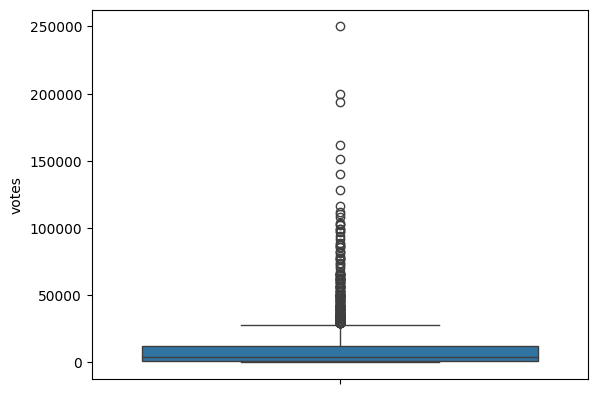

In [54]:
# outlier checking
sns.boxplot(df['votes'])

<Axes: ylabel='price_for_two'>

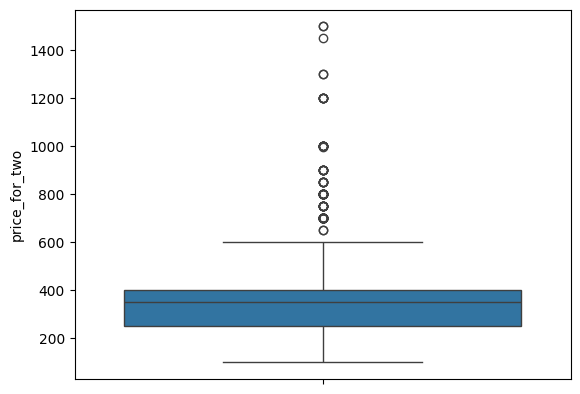

In [55]:
# outlier checking
sns.boxplot(df['price_for_two'])

Text(0, 0.5, 'count')

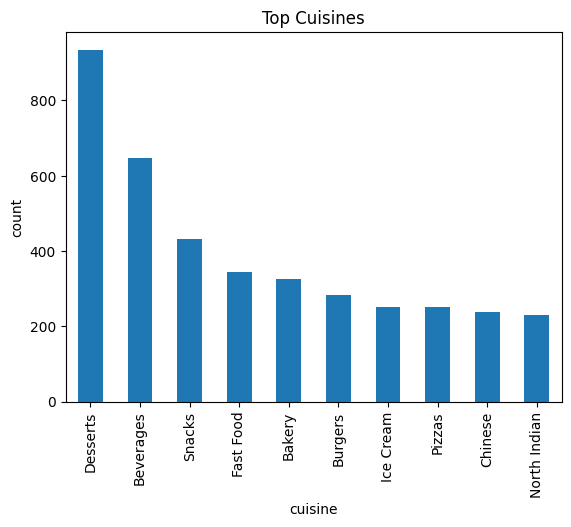

In [56]:
df['cuisine'].str.split(",").explode().str.strip().value_counts().head(10).plot(
    kind="bar",
    title="Top Cuisines"
)
plt.ylabel("count")
# explodes each cuisine as a separate row for each restaurant with all details same but each row only the cuisines will be different
# no. of rows will be how many cuisines are there in each restaurant

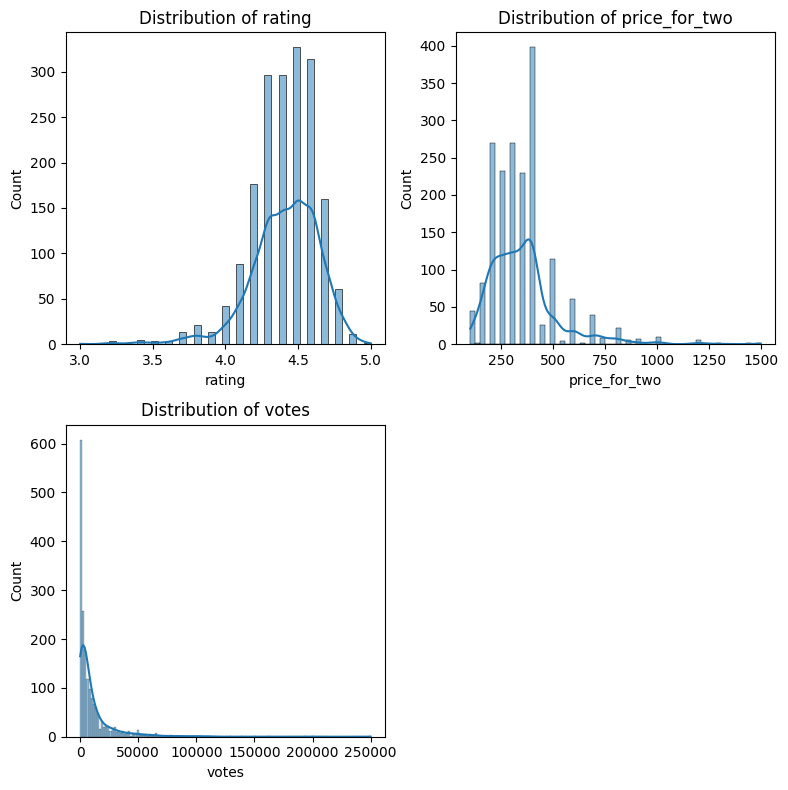

In [57]:
# distribution plots
columns=['rating','price_for_two','votes']
plt.figure(figsize=(8,8))
for i,col in enumerate(columns,1):
  plt.subplot(2,2,i)
  sns.histplot(df[col],kde=True)
  plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [58]:
# Top Rated Restaurants
top_restaurants = df.sort_values(by="rating",ascending=False).head(30)
top_restaurants

,name,city,area,cuisine,rating,votes,has_online_delivery,price_for_two,success,cuisine_count
3864,Royce' Chocolate,pune,Viman Nagar,Desserts,5.0,294,1,750,0,1
1358,Gourmet Ice Cream Cakes by Baskin Robbins,chennai,Mahalakshmi Nagar,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,52,1,200,0,4
4936,Minus 30,coimbatore,Race Course,Ice Cream,4.9,131,1,350,0,1
3872,Gourmet Ice Cream Cakes by Baskin Robbins,pune,Viman Nagar,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,45,1,250,0,4
3479,Gourmet Ice Cream Cakes by Baskin Robbins,kolkata,Rajarhat,"Desserts, Ice Cream, Bakery",4.9,32,1,400,0,3
2067,Royce' Chocolate,mumbai,Bandra West,Desserts,4.9,1400,1,750,1,1
3295,Gourmet Ice Cream Cakes by Baskin Robbins,kochi,PERUMBAVOOR,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,9,1,200,0,4
3073,Gourmet Ice Cream Cakes by Baskin Robbins,kochi,Kaloor,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,216,1,250,0,4
3344,Gourmet Ice Cream Cakes by Baskin Robbins,kochi,KTDC SHOPPING COMPLEX,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,5,1,200,0,4
3091,Caravan Ice Creams,kochi,Panampilly Nagar,Ice Cream,4.9,67,1,350,0,1


In [59]:
# Top Popular Restaurants having high no.of votes
top_voted = df.sort_values(by="votes",ascending=False).head(30)
top_voted

,name,city,area,cuisine,rating,votes,has_online_delivery,price_for_two,success,cuisine_count
2913,Alakapuri,kochi,Kakkanad,"South Indian, Kerala",4.7,250000,1,300,1,2
1805,Grill 9,hyderabad,Kharkhana & Trimulgherry,"Biryani, Chinese, Kebabs, Arabian, Lebanese",4.3,200000,1,400,1,5
1806,Paradise Biryani,hyderabad,Ramgopalpet,"Biryani, Kebabs, Hyderabadi, Rolls & Wraps",4.5,194000,1,400,1,4
4196,DMB Sweets Pvt Ltd,jaipur,C scheme,"Jain, South Indian, Snacks, Bengali, Italian, ...",4.5,162000,1,350,1,6
1754,Paradise Biryani,hyderabad,Hitech City,"Biryani, Kebabs, North Indian, Hyderabadi, Rol...",4.2,151000,1,400,1,5
4248,Dmb(Doodh Misthan Bhandar),jaipur,Bani Park,"Navratri Special, Thalis, Chinese, Continental...",4.6,140000,1,300,1,6
2179,Greens Restaurant,mumbai,Malad West,"Chinese, South Indian",4.6,128000,1,500,1,2
1740,Srikanya,hyderabad,Kondapur,"Biryani, Andhra, South Indian",4.3,116000,1,400,1,3
1862,Paradise Biryani,hyderabad,Begumpet,"Biryani, Kebabs, North Indian, Hyderabadi",4.2,112000,1,400,1,4
4924,Geetha Canteen,coimbatore,Gandhipuram,"South Indian, Indian, Chinese",4.6,110000,1,100,1,3


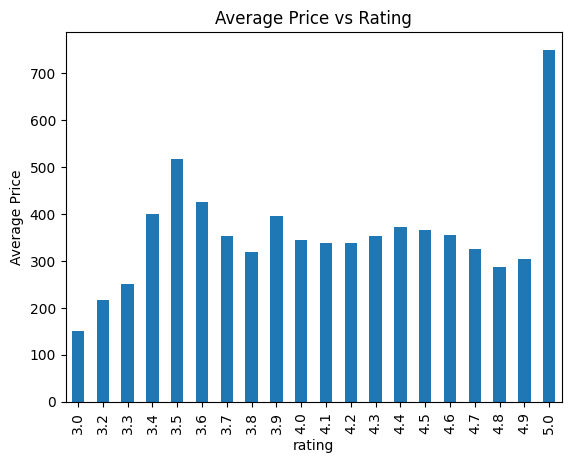

In [60]:
#Price vs Rating Relationship
df.groupby("rating")["price_for_two"].mean().plot(
    kind="bar",
    title="Average Price vs Rating"
)

plt.ylabel("Average Price")
plt.show()

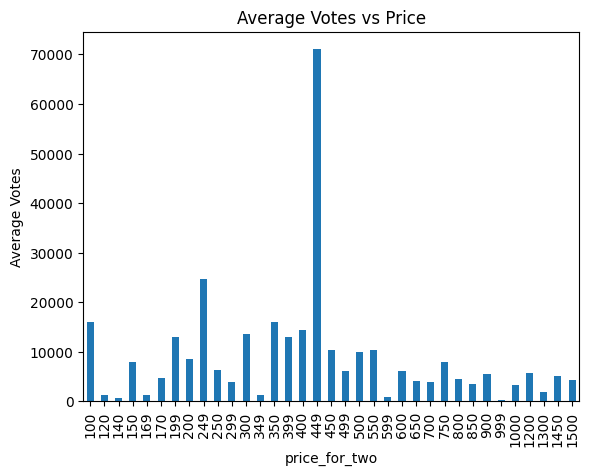

In [61]:
# Votes vs Price Relationship
df.groupby("price_for_two")["votes"].mean().plot(
    kind="bar",
    title="Average Votes vs Price"
)

plt.ylabel("Average Votes")
plt.show()

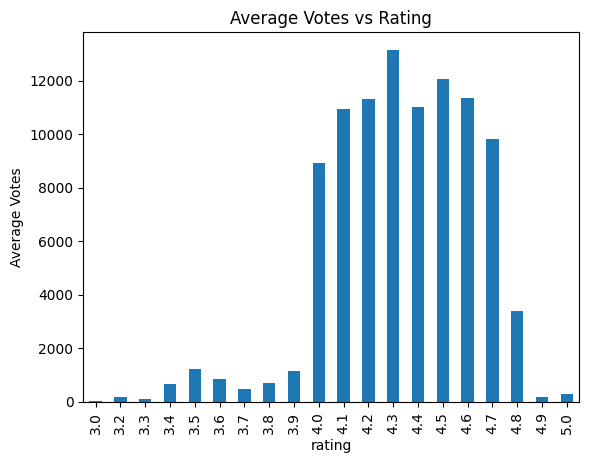

In [62]:
#Votes vs Rating Relationship
df.groupby("rating")["votes"].mean().plot(
    kind="bar",
    title="Average Votes vs Rating"
)

plt.ylabel("Average Votes")
plt.show()

# Feature Engineering

In [63]:
# null value handling- rating will with median as rating is slightly left skewed

In [64]:
# outlier handling- votes highly right skewed hence will log transform,
# price will leave without loosing actual meaning as it as not highly skewed like votes and few in number model can handle it